In [1]:
from src.dataset import prepare_datasets, tokenize
from src.augment import augment_backtranslation
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
from src.config import *


/Users/lance/Downloads/ML-Dir/fake-news-distilbert/fake-news-distilbert-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 512/512 [00:00<00:00, 40340.45it/s]


In [2]:
train_dataset, val_dataset, test_dataset = prepare_datasets()

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))


Train size: 2307
Val size: 257
Test size: 642


In [3]:
train_small = train_dataset.select(range(10))
val_small = val_dataset.select(range(10))
test_small = test_dataset.select(range(10))


In [4]:
print("=== RAW SAMPLE ===")
print(train_small[0][TEXT_COLUMN])
print("Label:", train_small[0]["label"])


=== RAW SAMPLE ===
Hindi magtatagumpay ang anumang impeachment complaint laban kay Pangulong Benigno S. Aquino III na may kaugnayan sa madugong Mamasapano operation dahil wala itong basehan, ayon sa isang opisyal ng Palasyo. At dahil kumpiyansa rin ang Malacanang na hindi susuportahan ng mga mambabatas ang ano mang hakbang na patalsikin si Pangulong Aquino, naniniwala rin si Presidential Communications Operations Secretary Herminio Coloma Jr. na hindi nilabag ng Punong Ehekutibo ang Konstitusyon o trinaydor ang sambayanan hinggil sa naturang isyu. "The President has kept faith with the people's mandate. In all of his actions, he has abided by his sworn duty to preserve and defend the Constitution, do justice to every Filipino and promote the national interest," pahayag ni Coloma sa text message. "Fair minded representatives will find no basis for an impeachment complaint," dagdag niya. Ito ang reaksiyon ni Coloma sa mga ulat na tinutumbok ng ilang mambabatas ang posibilidad na maghain 

In [5]:
baseline = augment_backtranslation(train_small, mode=None)
en_bt = augment_backtranslation(train_small, mode="en")
ko_bt = augment_backtranslation(train_small, mode="ko")


Map: 100%|██████████| 10/10 [19:50<00:00, 119.03s/ examples]


In [6]:
for i in range(3):
    print("\n====================")
    print("RAW :", train_small[i][TEXT_COLUMN])
    print("BASE:", baseline[i][TEXT_COLUMN])
    print("EN  :", en_bt[i][TEXT_COLUMN])
    print("KO  :", ko_bt[i][TEXT_COLUMN])



RAW : Hindi magtatagumpay ang anumang impeachment complaint laban kay Pangulong Benigno S. Aquino III na may kaugnayan sa madugong Mamasapano operation dahil wala itong basehan, ayon sa isang opisyal ng Palasyo. At dahil kumpiyansa rin ang Malacanang na hindi susuportahan ng mga mambabatas ang ano mang hakbang na patalsikin si Pangulong Aquino, naniniwala rin si Presidential Communications Operations Secretary Herminio Coloma Jr. na hindi nilabag ng Punong Ehekutibo ang Konstitusyon o trinaydor ang sambayanan hinggil sa naturang isyu. "The President has kept faith with the people's mandate. In all of his actions, he has abided by his sworn duty to preserve and defend the Constitution, do justice to every Filipino and promote the national interest," pahayag ni Coloma sa text message. "Fair minded representatives will find no basis for an impeachment complaint," dagdag niya. Ito ang reaksiyon ni Coloma sa mga ulat na tinutumbok ng ilang mambabatas ang posibilidad na maghain ng impeachme

In [8]:
sample = tokenize({"article": [train_small[0][TEXT_COLUMN]]})

print(sample.keys())
print({k: v.shape for k, v in sample.items() if hasattr(v, "shape")})


KeysView({'input_ids': [[101, 31341, 20722, 29464, 55792, 11359, 10157, 10488, 16642, 45306, 10211, 76484, 10269, 10426, 10212, 88975, 10123, 34025, 10115, 19314, 18661, 64539, 10376, 70552, 27285, 156, 119, 64775, 10652, 10132, 11387, 10730, 19951, 30771, 10206, 10148, 10824, 11460, 41685, 35771, 10466, 15119, 10133, 20080, 34434, 26592, 19694, 10376, 11404, 11781, 117, 11538, 10263, 10148, 12973, 108593, 30024, 10743, 78722, 93789, 10133, 119, 11699, 34434, 15694, 35407, 15976, 10466, 42840, 10488, 58335, 33793, 10376, 10132, 24823, 10846, 14590, 16312, 26019, 10743, 11136, 20933, 51382, 48389, 10488, 12797, 23912, 35943, 26337, 10132, 20194, 20162, 49364, 10294, 18661, 64539, 10376, 64775, 117, 10799, 11778, 95113, 42840, 10294, 55505, 27428, 36256, 19382, 13229, 37249, 10133, 75473, 10369, 12966, 119, 10132, 24823, 10414, 41284, 14520, 10743, 153, 25091, 10376, 29999, 54062, 68514, 10488, 30186, 40300, 27130, 15820, 183, 15633, 30771, 11849, 10488, 99928, 101182, 19911, 20964, 1016

In [9]:
model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6142.53it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
args = TrainingArguments(
    output_dir="./sanity_test",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=1,
    logging_steps=1,
    eval_strategy="epoch",
    disable_tqdm=False
)


In [12]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=baseline.map(tokenize, batched=True),
    eval_dataset=val_small.map(tokenize, batched=True),
)

trainer.train()


Map: 100%|██████████| 10/10 [00:00<00:00, 942.60 examples/s]
/Users/lance/Downloads/ML-Dir/fake-news-distilbert/fake-news-distilbert-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,0.664044,0.701588


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.58it/s]
/Users/lance/Downloads/ML-Dir/fake-news-distilbert/fake-news-distilbert-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=5, training_loss=0.7014663815498352, metrics={'train_runtime': 8.1575, 'train_samples_per_second': 1.226, 'train_steps_per_second': 0.613, 'total_flos': 1324673986560.0, 'train_loss': 0.7014663815498352, 'epoch': 1.0})

In [13]:
baseline_results = trainer.evaluate(test_small.map(tokenize, batched=True))
baseline_results


Map: 100%|██████████| 10/10 [00:00<00:00, 451.20 examples/s]


Training Loss,Validation Loss,Epoch
0.664044,0.696830,1


{'eval_loss': 0.6968299746513367}

In [14]:
model_en = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

trainer_en = Trainer(
    model=model_en,
    args=args,
    train_dataset=en_bt.map(tokenize, batched=True),
    eval_dataset=val_small.map(tokenize, batched=True),
)

trainer_en.train()


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6010.24it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 10/10 [00:00<00:00, 1218.32 examples/s]


Epoch,Training Loss,Validation Loss
1,0.722157,0.799788


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.44it/s]
/Users/lance/Downloads/ML-Dir/fake-news-distilbert/fake-news-distilbert-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=5, training_loss=0.7236979722976684, metrics={'train_runtime': 5.7629, 'train_samples_per_second': 1.735, 'train_steps_per_second': 0.868, 'total_flos': 1324673986560.0, 'train_loss': 0.7236979722976684, 'epoch': 1.0})

In [15]:
en_results = trainer_en.evaluate(test_small.map(tokenize, batched=True))
en_results


Training Loss,Validation Loss,Epoch
0.722157,0.774435,1


{'eval_loss': 0.7744349241256714}

In [16]:
model_ko = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

trainer_ko = Trainer(
    model=model_ko,
    args=args,
    train_dataset=ko_bt.map(tokenize, batched=True),
    eval_dataset=val_small.map(tokenize, batched=True),
)

trainer_ko.train()


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6743.04it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 10/10 [00:00<00:00, 792.07 examples/s]


Epoch,Training Loss,Validation Loss
1,0.686298,0.724789


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.57it/s]
/Users/lance/Downloads/ML-Dir/fake-news-distilbert/fake-news-distilbert-env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=5, training_loss=0.7021050810813904, metrics={'train_runtime': 8.9465, 'train_samples_per_second': 1.118, 'train_steps_per_second': 0.559, 'total_flos': 1324673986560.0, 'train_loss': 0.7021050810813904, 'epoch': 1.0})

In [17]:
ko_results = trainer_ko.evaluate(test_small.map(tokenize, batched=True))
ko_results


Training Loss,Validation Loss,Epoch
0.686298,0.715441,1


{'eval_loss': 0.7154413461685181}

In [20]:
import pandas as pd
import matplotlib as plt

results = pd.DataFrame([
    {"experiment": "baseline", **baseline_results},
    {"experiment": "en_bt", **en_results},
    {"experiment": "ko_bt", **ko_results},
])

results


,experiment,eval_loss
0,baseline,0.696830
1,en_bt,0.774435
2,ko_bt,0.715441


<Axes: xlabel='experiment'>

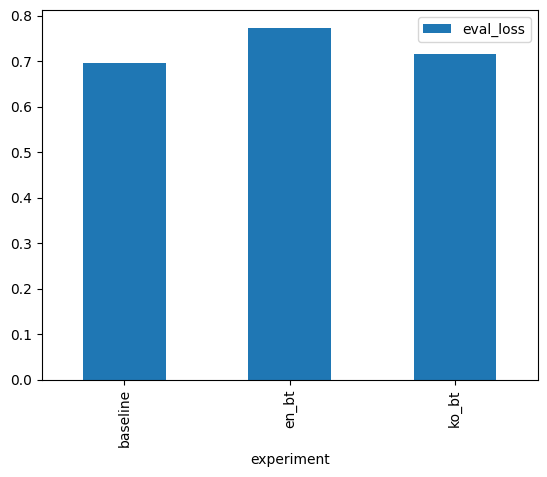

In [21]:
results.set_index("experiment").plot(kind="bar")
